In [2]:
'''from google.colab import drive
drive.mount('/content/drive')'''

"from google.colab import drive\ndrive.mount('/content/drive')"

In [17]:
import os
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import time

# for data augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [30]:
# Flame dataset paths
images_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/flame_dataset/images"
masks_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/flame_dataset/masks"

# path to save models, history and results
SAVE_DIR = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/flame_dataset/flame_model_unet_resnet34_focal"
os.makedirs(SAVE_DIR, exist_ok=True)

In [5]:
#corsican
'''images_path = "/content/drive/MyDrive/ColabNotebooks/ML2/images"
masks_path = "/content/drive/MyDrive/ColabNotebooks/ML2/masks"
SAVE_DIR = "/content/drive/MyDrive/ColabNotebooks/ML2/corsican_models_resnet34"
os.makedirs(SAVE_DIR, exist_ok=True)'''

'images_path = "/content/drive/MyDrive/ColabNotebooks/ML2/images"\nmasks_path = "/content/drive/MyDrive/ColabNotebooks/ML2/masks"\nSAVE_DIR = "/content/drive/MyDrive/ColabNotebooks/ML2/corsican_models_resnet34"\nos.makedirs(SAVE_DIR, exist_ok=True)'

In [6]:
#boreal
'''images_path = "/content/drive/MyDrive/ColabNotebooks/ML2/boreal_dataset/images"
masks_path = "/content/drive/MyDrive/ColabNotebooks/ML2/boreal_dataset/masks"
SAVE_DIR = "/content/drive/MyDrive/ColabNotebooks/ML2/boreal_models_resnet34"
os.makedirs(SAVE_DIR, exist_ok=True)'''

'images_path = "/content/drive/MyDrive/ColabNotebooks/ML2/boreal_dataset/images"\nmasks_path = "/content/drive/MyDrive/ColabNotebooks/ML2/boreal_dataset/masks"\nSAVE_DIR = "/content/drive/MyDrive/ColabNotebooks/ML2/boreal_models_resnet34"\nos.makedirs(SAVE_DIR, exist_ok=True)'

In [7]:
'''class FireDataset(Dataset):
    def __init__(self, images_path, masks_path, transform=None):
        self.images_path = images_path
        self.masks_path = masks_path
        self.transform = transform

        self.images = sorted(os.listdir(images_path))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
      img_name = self.images[idx]

      img_path = os.path.join(self.images_path, img_name)
      mask_name = img_name.replace("_rgb", "_gt")
      mask_path = os.path.join(self.masks_path, mask_name)

      image = np.array(Image.open(img_path).convert("RGB"))
      mask = np.array(Image.open(mask_path).convert("L"))

      mask = (mask > 0).astype("float32")

      if self.transform:
          augmented = self.transform(image=image, mask=mask)
          image = augmented["image"]
          mask = augmented["mask"].unsqueeze(0)

      if image.shape[1] != 256 or image.shape[2] != 256:
          image = torch.nn.functional.interpolate(
              image.unsqueeze(0), size=(256, 256), mode="bilinear", align_corners=False
          ).squeeze(0)

      if mask.shape[1] != 256 or mask.shape[2] != 256:
          mask = torch.nn.functional.interpolate(
              mask.unsqueeze(0), size=(256, 256), mode="nearest"
          ).squeeze(0)

      return image, mask'''

'class FireDataset(Dataset):\n    def __init__(self, images_path, masks_path, transform=None):\n        self.images_path = images_path\n        self.masks_path = masks_path\n        self.transform = transform\n\n        self.images = sorted(os.listdir(images_path))\n\n    def __len__(self):\n        return len(self.images)\n\n    def __getitem__(self, idx):\n      img_name = self.images[idx]\n\n      img_path = os.path.join(self.images_path, img_name)\n      mask_name = img_name.replace("_rgb", "_gt")\n      mask_path = os.path.join(self.masks_path, mask_name)\n\n      image = np.array(Image.open(img_path).convert("RGB"))\n      mask = np.array(Image.open(mask_path).convert("L"))\n\n      mask = (mask > 0).astype("float32")\n\n      if self.transform:\n          augmented = self.transform(image=image, mask=mask)\n          image = augmented["image"]\n          mask = augmented["mask"].unsqueeze(0)\n\n      if image.shape[1] != 256 or image.shape[2] != 256:\n          image = torch.nn.f

In [19]:
class FireDataset(Dataset):
    def __init__(self, images_path, masks_path, transform=None):
        self.images_path = images_path
        self.masks_path = masks_path
        self.transform = transform
        self.images = sorted(os.listdir(images_path))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_path, img_name)

        mask_stem = os.path.splitext(img_name)[0].replace("_rgb", "_gt")
        candidates = [f for f in os.listdir(self.masks_path) if os.path.splitext(f)[0] == mask_stem]
        if not candidates:
            raise FileNotFoundError(f"No mask found for image: {img_name}")
        mask_path = os.path.join(self.masks_path, candidates[0])

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"))

        mask = (mask > 0).astype("float32")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"].unsqueeze(0)

        if image.shape[1] != 256 or image.shape[2] != 256:
            image = torch.nn.functional.interpolate(
                image.unsqueeze(0), size=(256, 256), mode="bilinear", align_corners=False
            ).squeeze(0)

        if mask.shape[1] != 256 or mask.shape[2] != 256:
            mask = torch.nn.functional.interpolate(
                mask.unsqueeze(0), size=(256, 256), mode="nearest"
            ).squeeze(0)

        return image, mask

In [20]:
#Data augmenattion
train_transform  = A.Compose([
    A.HorizontalFlip(p=0.5), # random flip
    A.VerticalFlip(p=0.5),
    A.Resize(256, 256), # resize
    A.HueSaturationValue(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

test_transform = val_transform

In [21]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [22]:
#loss function
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)

        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            preds.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

In [12]:
!pip install segmentation_models_pytorch

In [23]:
import segmentation_models_pytorch as smp
from torch.utils.data import Subset
import random

In [24]:
def create_data_splits(images_path, masks_path, train_transform, val_transform, data_percentage=1.0):
    """
    Create train/val/test splits using a percentage of the full dataset.
    Args:
        data_percentage: 0.25, 0.50 or 1.0
    Returns:
        train_dataset, val_dataset, test_dataset
    """
    total_size = len(FireDataset(images_path, masks_path))
    used_size  = int(total_size * data_percentage)

    train_size = int(0.70 * used_size)
    val_size   = int(0.15 * used_size)
    test_size  = used_size - train_size - val_size

    print(f'\nUsing {data_percentage*100:.0f}% of dataset:')
    print(f'  Total images : {total_size}')
    print(f'  Used images  : {used_size}')
    print(f'  Train        : {train_size}')
    print(f'  Val          : {val_size}')
    print(f'  Test         : {test_size}')

    full_train = FireDataset(images_path, masks_path, transform=train_transform)
    full_val   = FireDataset(images_path, masks_path, transform=val_transform)
    full_test  = FireDataset(images_path, masks_path, transform=val_transform)

    indices = list(range(total_size))
    random.seed(42)
    random.shuffle(indices)
    indices = indices[:used_size]

    train_idx = indices[:train_size]
    val_idx   = indices[train_size:train_size + val_size]
    test_idx  = indices[train_size + val_size:]

    train_dataset = Subset(full_train, train_idx)
    val_dataset   = Subset(full_val,   val_idx)
    test_dataset  = Subset(full_test,  test_idx)

    return train_dataset, val_dataset, test_dataset

In [25]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.manual_seed(42)
import numpy as np
np.random.seed(42)
random.seed(42)


Using device: cuda


In [26]:
def get_metrics(preds, targets, threshold=0.5):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    TP = (preds * targets).sum()
    TN = ((1 - preds) * (1 - targets)).sum()
    FP = (preds * (1 - targets)).sum()
    FN = ((1 - preds) * targets).sum()

    # F1 Score
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)

    # mIoU
    miou = TP / (TP + FP + FN + 1e-8)

    # MCC
    mcc = (TP * TN - FP * FN) / torch.sqrt(
        (TP + FP) * (TP + FN) * (TN + FP) * (TN + FN) + 1e-8
    )

    # HAF (igual a IoU en binario, pero lo dejamos explícito)
    haf = TP / (TP + FP + FN + 1e-8)

    return f1.item(), miou.item(), mcc.item(), haf.item()

In [27]:
class EarlyStopping:
    """
    Stops training when val_loss does not improve for `patience` consecutive epochs.
    Also saves the best model weights.
    """
    def __init__(self, patience=10, min_delta=1e-4, verbose=True):
        """
        Args:
            patience  : epochs to wait without improvement before stopping
            min_delta : minimum change to count as an improvement
            verbose   : print a message each time the counter increases
        """
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.best_weights = None
        self.stop       = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            # Improvement found
            self.best_loss    = val_loss
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter      = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f"  EarlyStopping: no improvement for {self.counter}/{self.patience} epochs "
                      f"(best val_loss={self.best_loss:.4f})")
            if self.counter >= self.patience:
                self.stop = True

    def restore_best_weights(self, model):
        """Load the best weights back into the model."""
        model.load_state_dict(self.best_weights)
        print(f"  Best weights restored (val_loss={self.best_loss:.4f})")

In [31]:
import json as _json

BATCH_SIZE = 8
NUM_EPOCHS = 50

def train_model(train_loader, val_loader, test_loader, data_percentage, num_epochs=50):
    pct_tag  = int(data_percentage * 100)
    pct_str  = f"{pct_tag}%"
    model_path   = os.path.join(SAVE_DIR, f"model_{pct_tag}.pth")
    history_path = os.path.join(SAVE_DIR, f"history_{pct_tag}.json")
    results_path = os.path.join(SAVE_DIR, f"results_{pct_tag}.json")

    if os.path.exists(model_path) and os.path.exists(history_path) and os.path.exists(results_path):
        print(f'\n{"="*70}')
        print(f'Model {pct_str} already trained. Loading from Drive...')
        print(f'{"="*70}\n')

        model = smp.Unet(
            encoder_name='resnet34',
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None
        ).to(device)

        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()

        with open(history_path) as f:
            history = _json.load(f)
        with open(results_path) as f:
            test_results = _json.load(f)

        print(f"  Val mIoU guardado : {checkpoint['val_miou']:.4f}")
        print(f"  Test mIoU guardado: {test_results['test_miou']:.4f}")

        # Obtain infernece time
        model.eval()
        dummy_input = torch.randn(1, 3, 256, 256).to(device)

        # Warmup: first 10 passes to avoid cold start effects
        with torch.no_grad():
            for _ in range(10):
                _ = model(dummy_input)

        # Meassuring: 100 passes to get a stable average inference time
        times = []
        with torch.no_grad():
            for _ in range(100):
                start = time.perf_counter()
                _ = model(dummy_input)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                end = time.perf_counter()
                times.append(end - start)

        inference_ms = (sum(times) / len(times)) * 1000
        print(f"  Inference time ({pct_str}): {inference_ms:.2f} ms/img")

        test_results['inference_ms'] = round(inference_ms, 4)

        with open(results_path, 'w') as f:
            _json.dump(test_results, f)

        return history, test_results, model

    import gc
    gc.collect()
    torch.cuda.empty_cache()

    print(f'\n{"="*70}')
    print(f'TRAINING WITH {pct_str} OF DATASET')
    print(f'{"="*70}\n')

    model = smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
        activation=None
    ).to(device)

    # using Dice loss only
    '''criterion = DiceLoss()''' 
    
    # using Dice loss + BCE loss
    '''_dice = DiceLoss()
    _bce = nn.BCEWithLogitsLoss()
    def criterion(preds, targets):
        return _dice(preds, targets) + _bce(preds, targets.float())'''
    
    #using Focal loss 
    _focal = smp.losses.FocalLoss(mode='binary')

    def criterion(preds, targets):
        return _focal(preds, targets.float())

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    early_stopping = EarlyStopping(patience=10, min_delta=1e-4, verbose=True)

    best_val_miou  = 0.0
    history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[],
               'train_miou':[], 'val_miou':[], 'train_mcc':[], 'val_mcc':[]}

    for epoch in range(num_epochs):
        # --- TRAIN ---
        model.train()
        train_loss, train_metrics = 0, [0]*4
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            metrics = get_metrics(outputs, masks)
            train_metrics = [x + y for x, y in zip(train_metrics, metrics)]
        train_loss /= len(train_loader)
        train_metrics = [x / len(train_loader) for x in train_metrics]

        # --- VALIDATION ---
        model.eval()
        val_loss, val_metrics = 0, [0]*4
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                metrics = get_metrics(outputs, masks)
                val_metrics = [x + y for x, y in zip(val_metrics, metrics)]
        val_loss /= len(val_loader)
        val_metrics = [x / len(val_loader) for x in val_metrics]

        # --- LOG HISTORY ---
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_metrics[0])
        history['val_f1'].append(val_metrics[0])
        history['train_miou'].append(train_metrics[1])
        history['val_miou'].append(val_metrics[1])
        history['train_mcc'].append(train_metrics[2])
        history['val_mcc'].append(val_metrics[2])

        # --- SAVE BEST MODEL ---
        val_miou = val_metrics[1]
        if val_miou > best_val_miou:
            best_val_miou = val_miou
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_miou': val_miou}, model_path)
            print(f'  [Epoch {epoch+1}] New best model saved (val_mIoU={val_miou:.4f})')

        # --- PRINT every 5 epochs ---
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'  Train - Loss: {train_loss:.4f}, F1: {train_metrics[0]:.4f}, mIoU: {train_metrics[1]:.4f}')
            print(f'  Val   - Loss: {val_loss:.4f}, F1: {val_metrics[0]:.4f}, mIoU: {val_metrics[1]:.4f}')

        # --- EARLY STOPPING ---
        early_stopping(val_loss, model)
        if early_stopping.stop:
            print(f'\n  Early stopping at epoch {epoch+1}')
            break

    early_stopping.restore_best_weights(model)

    # --- TEST ---
    model.eval()
    test_loss, test_metrics = 0, [0]*4
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            test_loss += loss.item()
            metrics = get_metrics(outputs, masks)
            test_metrics = [x + y for x, y in zip(test_metrics, metrics)]
    test_loss /= len(test_loader)
    test_metrics = [x / len(test_loader) for x in test_metrics]

    names = ['F1', 'mIoU', 'MCC', 'HAF']
    print(f'\n{"="*70}')
    print(f'RESULTS - {pct_str} Dataset')
    print(f'{"="*70}')
    print(f"\n{'Metric':<12} {'Train':>10} {'Val':>10} {'Test':>10}")
    print('-' * 45)
    for i, name in enumerate(names):
        print(f'{name:<12} {train_metrics[i]:>10.4f} {val_metrics[i]:>10.4f} {test_metrics[i]:>10.4f}')
    print('-' * 45)
    print(f"{'Loss':<12} {train_loss:>10.4f} {val_loss:>10.4f} {test_loss:>10.4f}")

    test_results = {
        'test_loss': test_loss,
        'test_f1':   test_metrics[0],
        'test_miou': test_metrics[1],
        'test_mcc':  test_metrics[2],
        'test_haf':  test_metrics[3],
        'train_f1':  train_metrics[0],
        'train_miou':train_metrics[1],
        'train_mcc': train_metrics[2],
        'train_loss':train_loss,
        'val_f1':    val_metrics[0],
        'val_miou':  val_metrics[1],
        'val_mcc':   val_metrics[2],
        'val_loss':  val_loss,
    }

    with open(history_path, 'w') as f:
        _json.dump(history, f)
    with open(results_path, 'w') as f:
        _json.dump(test_results, f)
    print(f'\n  Saved in Drive:')
    print(f'    Modelo   : {model_path}')
    print(f'    Historial: {history_path}')
    print(f'    Resultados: {results_path}')

    # Obtain infernece time
    model.eval()
    dummy_input = torch.randn(1, 3, 256, 256).to(device)

    # Warmup: first 10 passes to avoid cold start effects
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy_input)

    # Meassuring: 100 passes to get a stable average inference time
    times = []
    with torch.no_grad():
        for _ in range(100):
            start = time.perf_counter()
            _ = model(dummy_input)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end = time.perf_counter()
            times.append(end - start)

    inference_ms = (sum(times) / len(times)) * 1000
    print(f"  Inference time ({pct_str}): {inference_ms:.2f} ms/img")

    test_results['inference_ms'] = round(inference_ms, 4)

    with open(results_path, 'w') as f:
        _json.dump(test_results, f)

    return history, test_results, model


In [32]:
train_25, val_25, test_25 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=0.25)

train_loader_25 = DataLoader(train_25, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_25   = DataLoader(val_25,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_25  = DataLoader(test_25,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_25, test_results_25, model_25 = train_model(
    train_loader_25, val_loader_25, test_loader_25,
    data_percentage=0.25, num_epochs=NUM_EPOCHS)


Using 25% of dataset:
  Total images : 2003
  Used images  : 500
  Train        : 350
  Val          : 75
  Test         : 75

TRAINING WITH 25% OF DATASET

  [Epoch 1] New best model saved (val_mIoU=0.0125)
Epoch [1/50]
  Train - Loss: 0.2040, F1: 0.0132, mIoU: 0.0067
  Val   - Loss: 0.1344, F1: 0.0247, mIoU: 0.0125
  [Epoch 3] New best model saved (val_mIoU=0.0137)
  [Epoch 4] New best model saved (val_mIoU=0.0880)
  [Epoch 5] New best model saved (val_mIoU=0.1633)
Epoch [5/50]
  Train - Loss: 0.0307, F1: 0.2678, mIoU: 0.1567
  Val   - Loss: 0.0273, F1: 0.2770, mIoU: 0.1633
  [Epoch 6] New best model saved (val_mIoU=0.2352)
  [Epoch 7] New best model saved (val_mIoU=0.3091)
  [Epoch 8] New best model saved (val_mIoU=0.4849)
  [Epoch 9] New best model saved (val_mIoU=0.4980)
Epoch [10/50]
  Train - Loss: 0.0136, F1: 0.6770, mIoU: 0.5129
  Val   - Loss: 0.0137, F1: 0.6418, mIoU: 0.4754
  [Epoch 11] New best model saved (val_mIoU=0.5337)
  [Epoch 12] New best model saved (val_mIoU=0.57

In [33]:
train_50, val_50, test_50 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=0.50)

train_loader_50 = DataLoader(train_50, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_50   = DataLoader(val_50,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_50  = DataLoader(test_50,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_50, test_results_50, model_50 = train_model(
    train_loader_50, val_loader_50, test_loader_50,
    data_percentage=0.50, num_epochs=NUM_EPOCHS)



Using 50% of dataset:
  Total images : 2003
  Used images  : 1001
  Train        : 700
  Val          : 150
  Test         : 151

TRAINING WITH 50% OF DATASET

  [Epoch 1] New best model saved (val_mIoU=0.0408)
Epoch [1/50]
  Train - Loss: 0.1265, F1: 0.0307, mIoU: 0.0157
  Val   - Loss: 0.0532, F1: 0.0780, mIoU: 0.0408
  [Epoch 2] New best model saved (val_mIoU=0.1831)
  [Epoch 3] New best model saved (val_mIoU=0.4402)
  [Epoch 4] New best model saved (val_mIoU=0.4892)
  [Epoch 5] New best model saved (val_mIoU=0.5969)
Epoch [5/50]
  Train - Loss: 0.0093, F1: 0.7154, mIoU: 0.5584
  Val   - Loss: 0.0078, F1: 0.7465, mIoU: 0.5969
  [Epoch 6] New best model saved (val_mIoU=0.6098)
  [Epoch 7] New best model saved (val_mIoU=0.6282)
  [Epoch 8] New best model saved (val_mIoU=0.6518)
  [Epoch 10] New best model saved (val_mIoU=0.6578)
Epoch [10/50]
  Train - Loss: 0.0035, F1: 0.7952, mIoU: 0.6606
  Val   - Loss: 0.0033, F1: 0.7926, mIoU: 0.6578
  [Epoch 11] New best model saved (val_mIoU=0

In [34]:
train_100, val_100, test_100 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=1.0)

train_loader_100 = DataLoader(train_100, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_100   = DataLoader(val_100,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_100  = DataLoader(test_100,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_100, test_results_100, model_100 = train_model(
    train_loader_100, val_loader_100, test_loader_100,
    data_percentage=1.0, num_epochs=NUM_EPOCHS)


Using 100% of dataset:
  Total images : 2003
  Used images  : 2003
  Train        : 1402
  Val          : 300
  Test         : 301

TRAINING WITH 100% OF DATASET

  [Epoch 1] New best model saved (val_mIoU=0.5723)
Epoch [1/50]
  Train - Loss: 0.0182, F1: 0.4394, mIoU: 0.3202
  Val   - Loss: 0.0053, F1: 0.7269, mIoU: 0.5723
  [Epoch 2] New best model saved (val_mIoU=0.6529)
  [Epoch 3] New best model saved (val_mIoU=0.6898)
  [Epoch 4] New best model saved (val_mIoU=0.7000)
  [Epoch 5] New best model saved (val_mIoU=0.7174)
Epoch [5/50]
  Train - Loss: 0.0017, F1: 0.8175, mIoU: 0.6922
  Val   - Loss: 0.0016, F1: 0.8352, mIoU: 0.7174
  [Epoch 6] New best model saved (val_mIoU=0.7287)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.0016)
  [Epoch 7] New best model saved (val_mIoU=0.7360)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.0014)
  [Epoch 9] New best model saved (val_mIoU=0.7456)
  [Epoch 10] New best model saved (val_mIoU=0.7573)
Epoch [10/50

In [35]:
all_test_results = {'25%': test_results_25, '50%': test_results_50, '100%': test_results_100}

print('=' * 95)
print('SUMMARY: TEST SET RESULTS FOR DIFFERENT DATASET SIZES')
print('=' * 95)
print(f"{'Dataset':<12} {'Loss':<10} {'F1':<10} {'mIoU':<10} {'MCC':<10} {'HAF':<10} {'Inference (ms)':<14}")
print('-' * 95)
for pct in ['25%', '50%', '100%']:
    r = all_test_results[pct]
    inf_ms = r.get('inference_ms', float('nan'))
    print(f"{pct:<12} {r['test_loss']:<10.4f} {r['test_f1']:<10.4f} "
          f"{r['test_miou']:<10.4f} {r['test_mcc']:<10.4f} {r['test_haf']:<10.4f} {inf_ms:<14.2f}")
print('=' * 95)

SUMMARY: TEST SET RESULTS FOR DIFFERENT DATASET SIZES
Dataset      Loss       F1         mIoU       MCC        HAF        Inference (ms)
-----------------------------------------------------------------------------------------------
25%          0.0019     0.8538     0.7455     0.8531     0.7455     4.95          
50%          0.0011     0.8624     0.7584     0.8622     0.7584     4.73          
100%         0.0010     0.8670     0.7654     0.8665     0.7654     4.79          


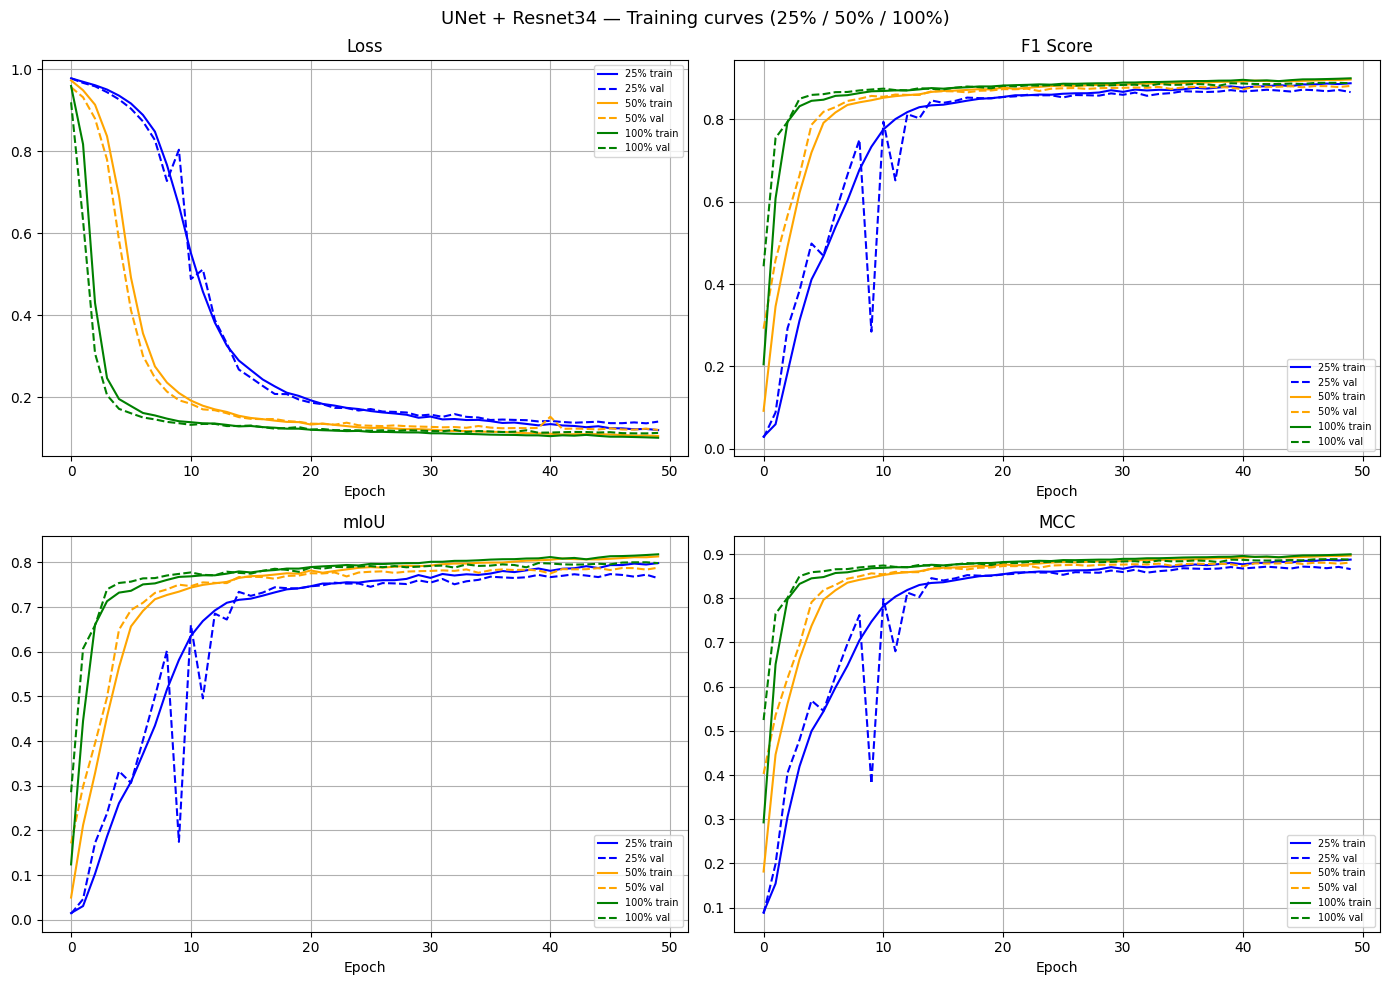

In [23]:
import matplotlib.pyplot as plt

all_histories = {'25%': history_25, '50%': history_50, '100%': history_100}
titles = ['Loss', 'F1 Score', 'mIoU', 'MCC']
keys   = [('train_loss','val_loss'), ('train_f1','val_f1'),
          ('train_miou','val_miou'), ('train_mcc','val_mcc')]
colors = {'25%':'blue', '50%':'orange', '100%':'green'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, title, (tk, vk) in zip(axes, titles, keys):
    for pct, hist in all_histories.items():
        c = colors[pct]
        ax.plot(hist[tk], color=c, linestyle='-',  label=f'{pct} train')
        ax.plot(hist[vk], color=c, linestyle='--', label=f'{pct} val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=7)
    ax.grid(True)

plt.suptitle('UNet + Resnet34 — Training curves (25% / 50% / 100%)', fontsize=13)
plt.tight_layout()
plt.show()


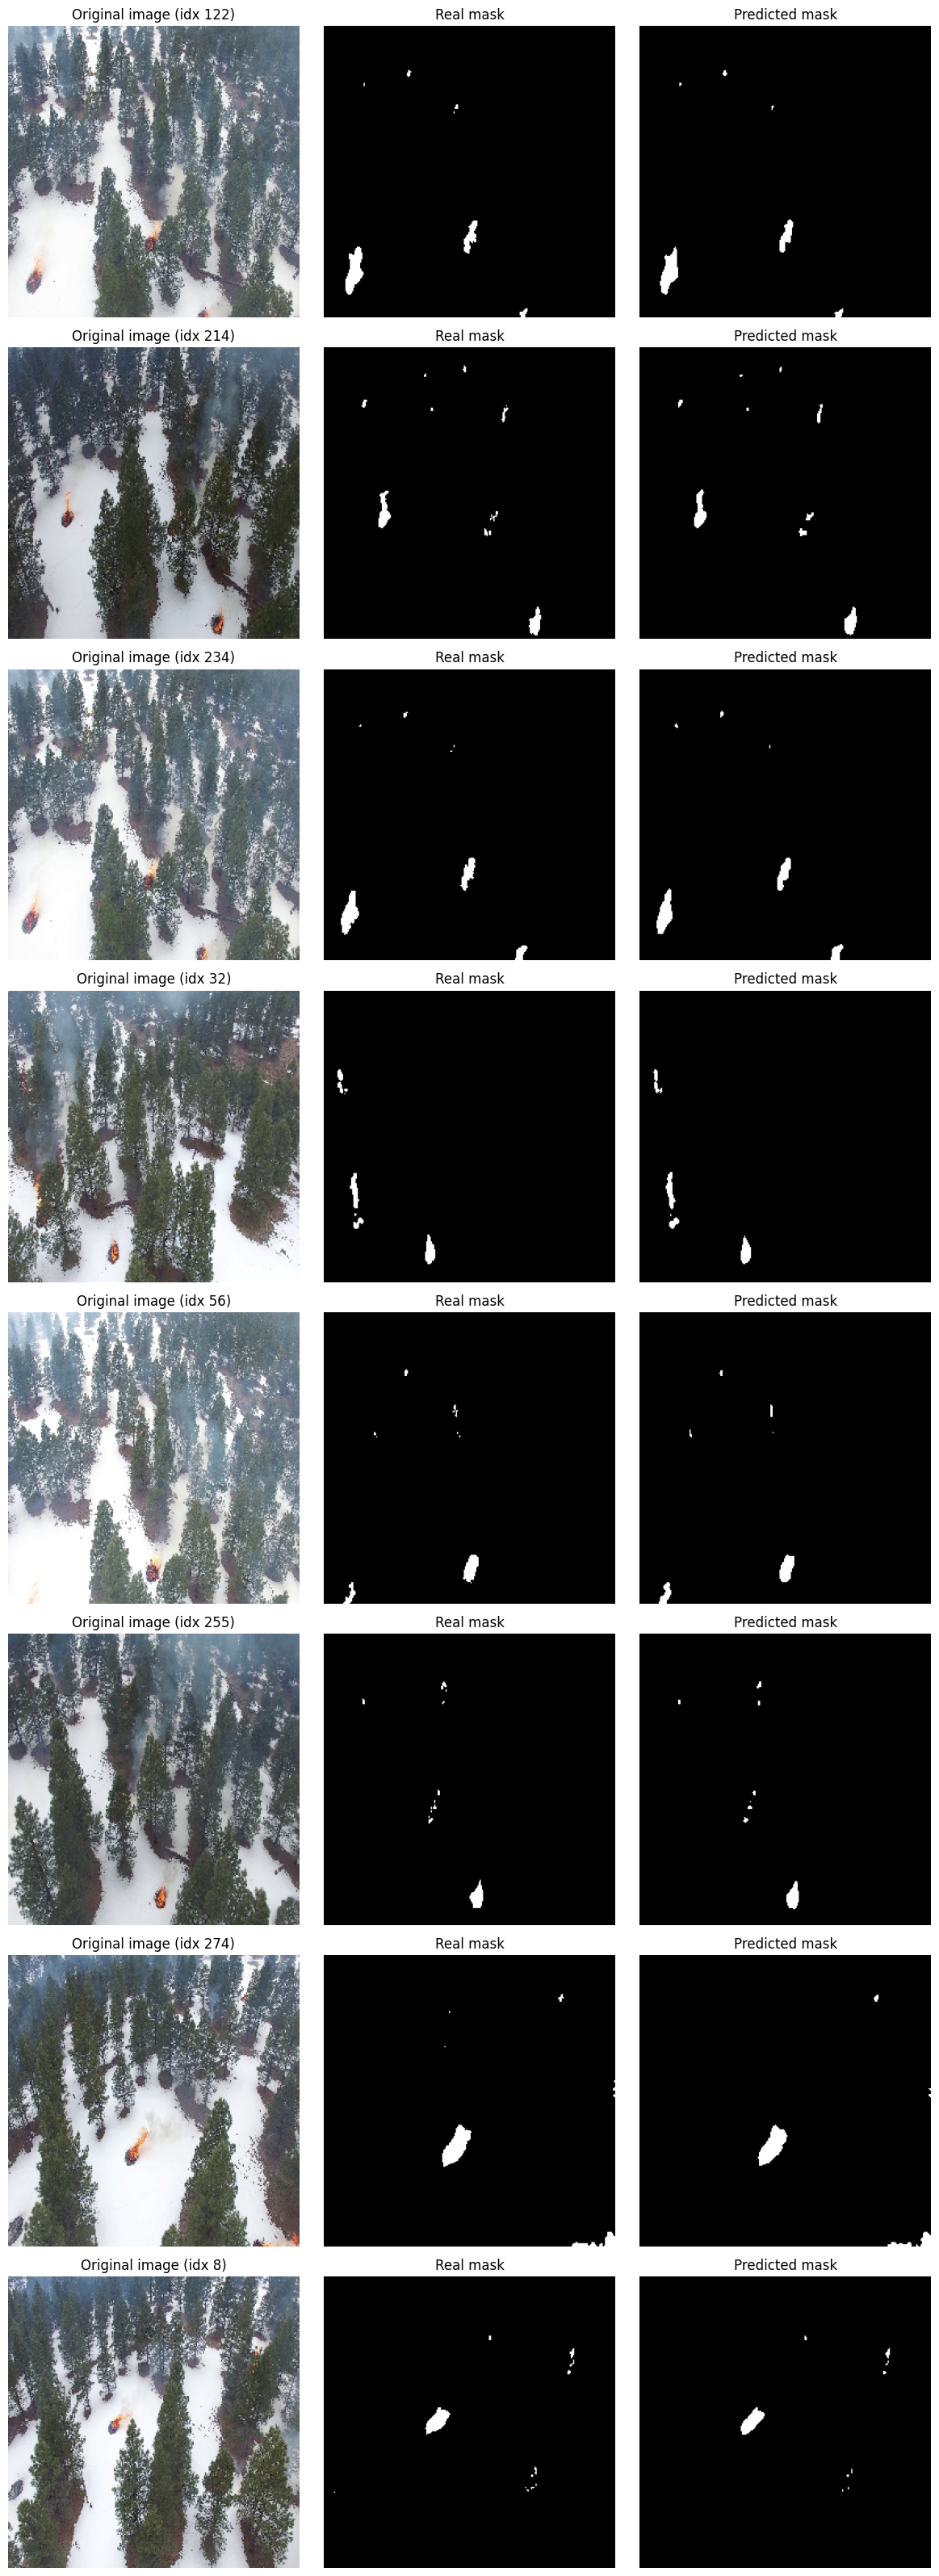

In [24]:
import matplotlib.pyplot as plt
import random

model_100.eval()

# Sample 8 random images from the test set
num_imgs = 8
test_dataset = test_loader_100.dataset
random_indices = random.sample(range(len(test_dataset)), num_imgs)

# Build batch manually
images_list, masks_list = [], []
for idx in random_indices:
    img, mask = test_dataset[idx]
    images_list.append(img)
    masks_list.append(mask)

images = torch.stack(images_list).to(device)
masks  = torch.stack(masks_list)

with torch.no_grad():
    outputs = model_100(images)
    preds = torch.sigmoid(outputs)
    preds = (preds > 0.5).float()

# Desnormalizar para visualizar
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(num_imgs, 3, figsize=(12, num_imgs * 4))

for i in range(num_imgs):
    img       = images[i].cpu() * std + mean
    img       = img.permute(1, 2, 0).clamp(0, 1)
    mask_real = masks[i].cpu().squeeze()
    mask_pred = preds[i].cpu().squeeze()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Original image (idx {random_indices[i]})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_real, cmap="gray")
    axes[i, 1].set_title("Real mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(mask_pred, cmap="gray")
    axes[i, 2].set_title("Predicted mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

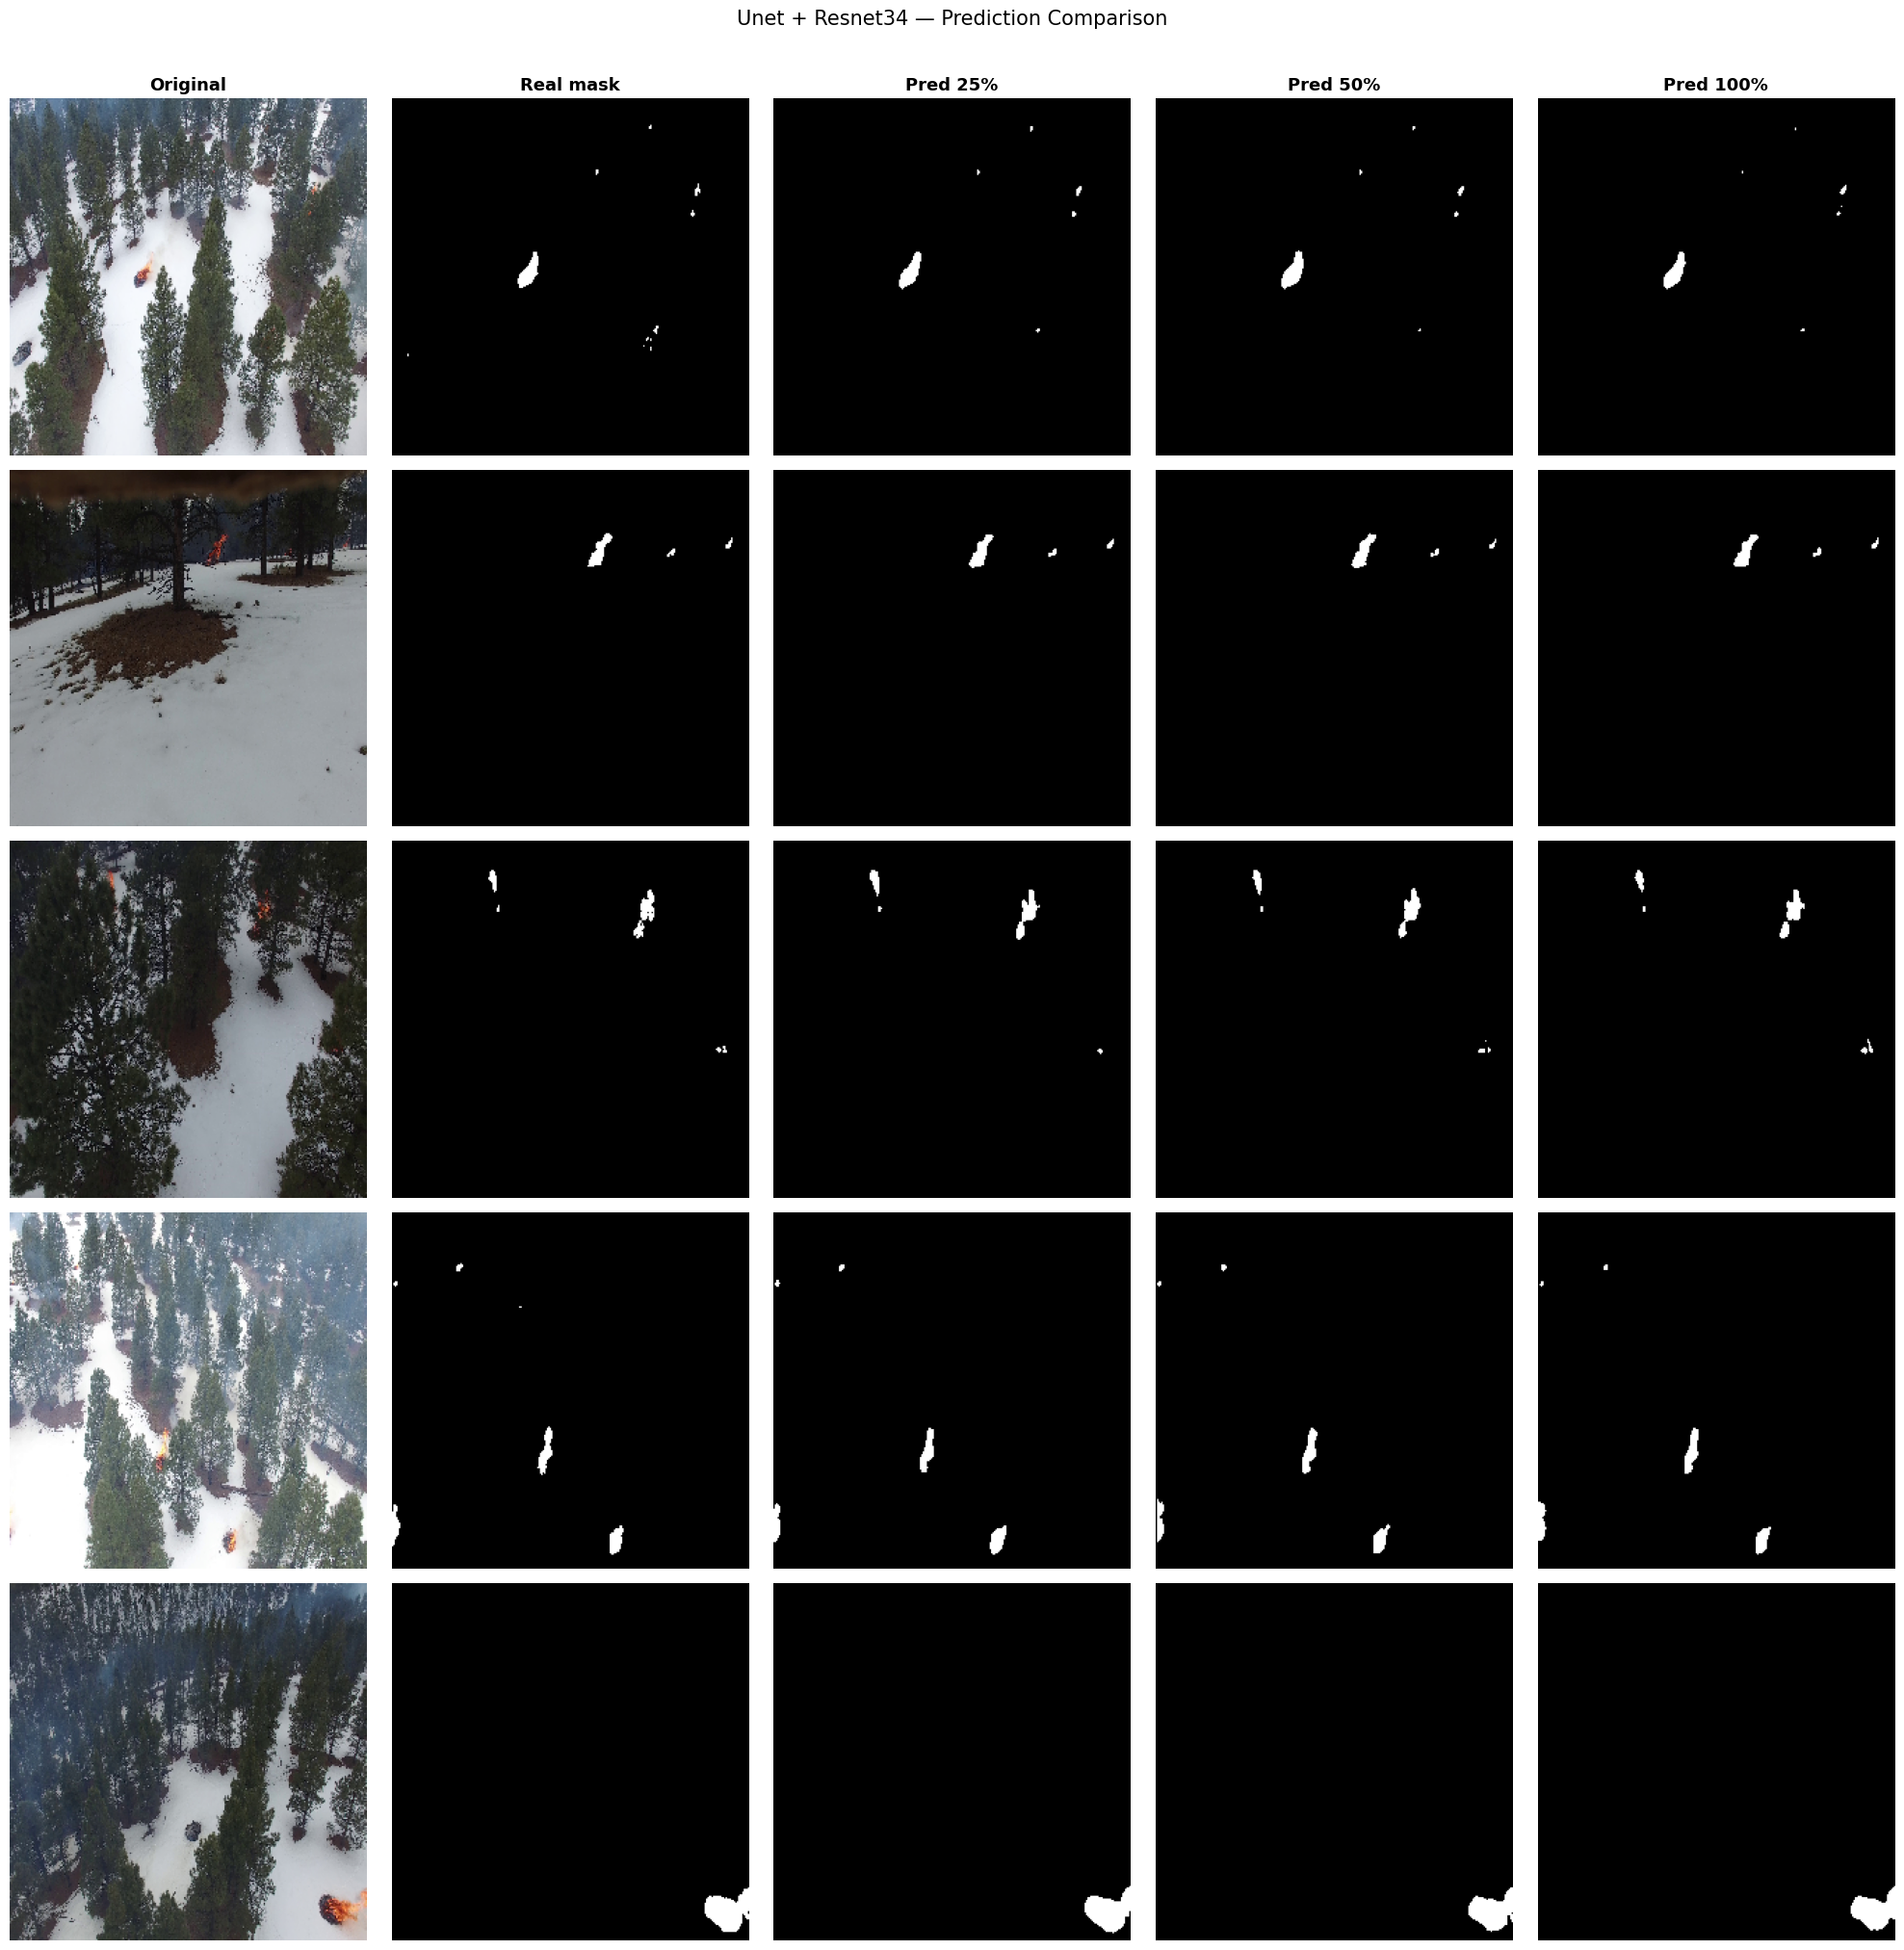

In [25]:
import matplotlib.pyplot as plt
import torch

fixed_indices = [10, 55, 150, 205, 279]
num_imgs = len(fixed_indices)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def predict(model, dataset, indices):
    images_list, masks_list = [], []
    for idx in indices:
        img, mask = dataset[idx]
        images_list.append(img)
        masks_list.append(mask)
    images = torch.stack(images_list).to(device)
    masks  = torch.stack(masks_list)
    with torch.no_grad():
        outputs = model(images)
        preds   = torch.sigmoid(outputs)
        preds   = (preds > 0.5).float()
    return images, masks, preds

# Get predictions for the same fixed indices from all 3 models
test_dataset = test_loader_100.dataset

images, masks, preds_25  = predict(model_25,  test_dataset, fixed_indices)
_,      _,     preds_50  = predict(model_50,  test_dataset, fixed_indices)
_,      _,     preds_100 = predict(model_100, test_dataset, fixed_indices)

# Columns: Imagen | Mask real | Pred 25% | Pred 50% | Pred 100%
fig, axes = plt.subplots(num_imgs, 5, figsize=(20, num_imgs * 4))

col_titles = ["Original", "Real mask", "Pred 25%", "Pred 50%", "Pred 100%"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold")

for i in range(num_imgs):
    img       = images[i].cpu() * std + mean
    img       = img.permute(1, 2, 0).clamp(0, 1)
    mask_real = masks[i].cpu().squeeze()
    pred_25   = preds_25[i].cpu().squeeze()
    pred_50   = preds_50[i].cpu().squeeze()
    pred_100  = preds_100[i].cpu().squeeze()

    axes[i, 0].imshow(img)
    axes[i, 0].set_ylabel(f"idx {fixed_indices[i]}", fontsize=10)

    axes[i, 1].imshow(mask_real, cmap="gray")
    axes[i, 2].imshow(pred_25,   cmap="gray")
    axes[i, 3].imshow(pred_50,   cmap="gray")
    axes[i, 4].imshow(pred_100,  cmap="gray")

    for col in range(5):
        axes[i, col].axis("off")
    #axes[i, 0].axis("on")
    axes[i, 0].tick_params(left=False, bottom=False, labelleft=True, labelbottom=False)

plt.suptitle("Unet + Resnet34 — Prediction Comparison", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

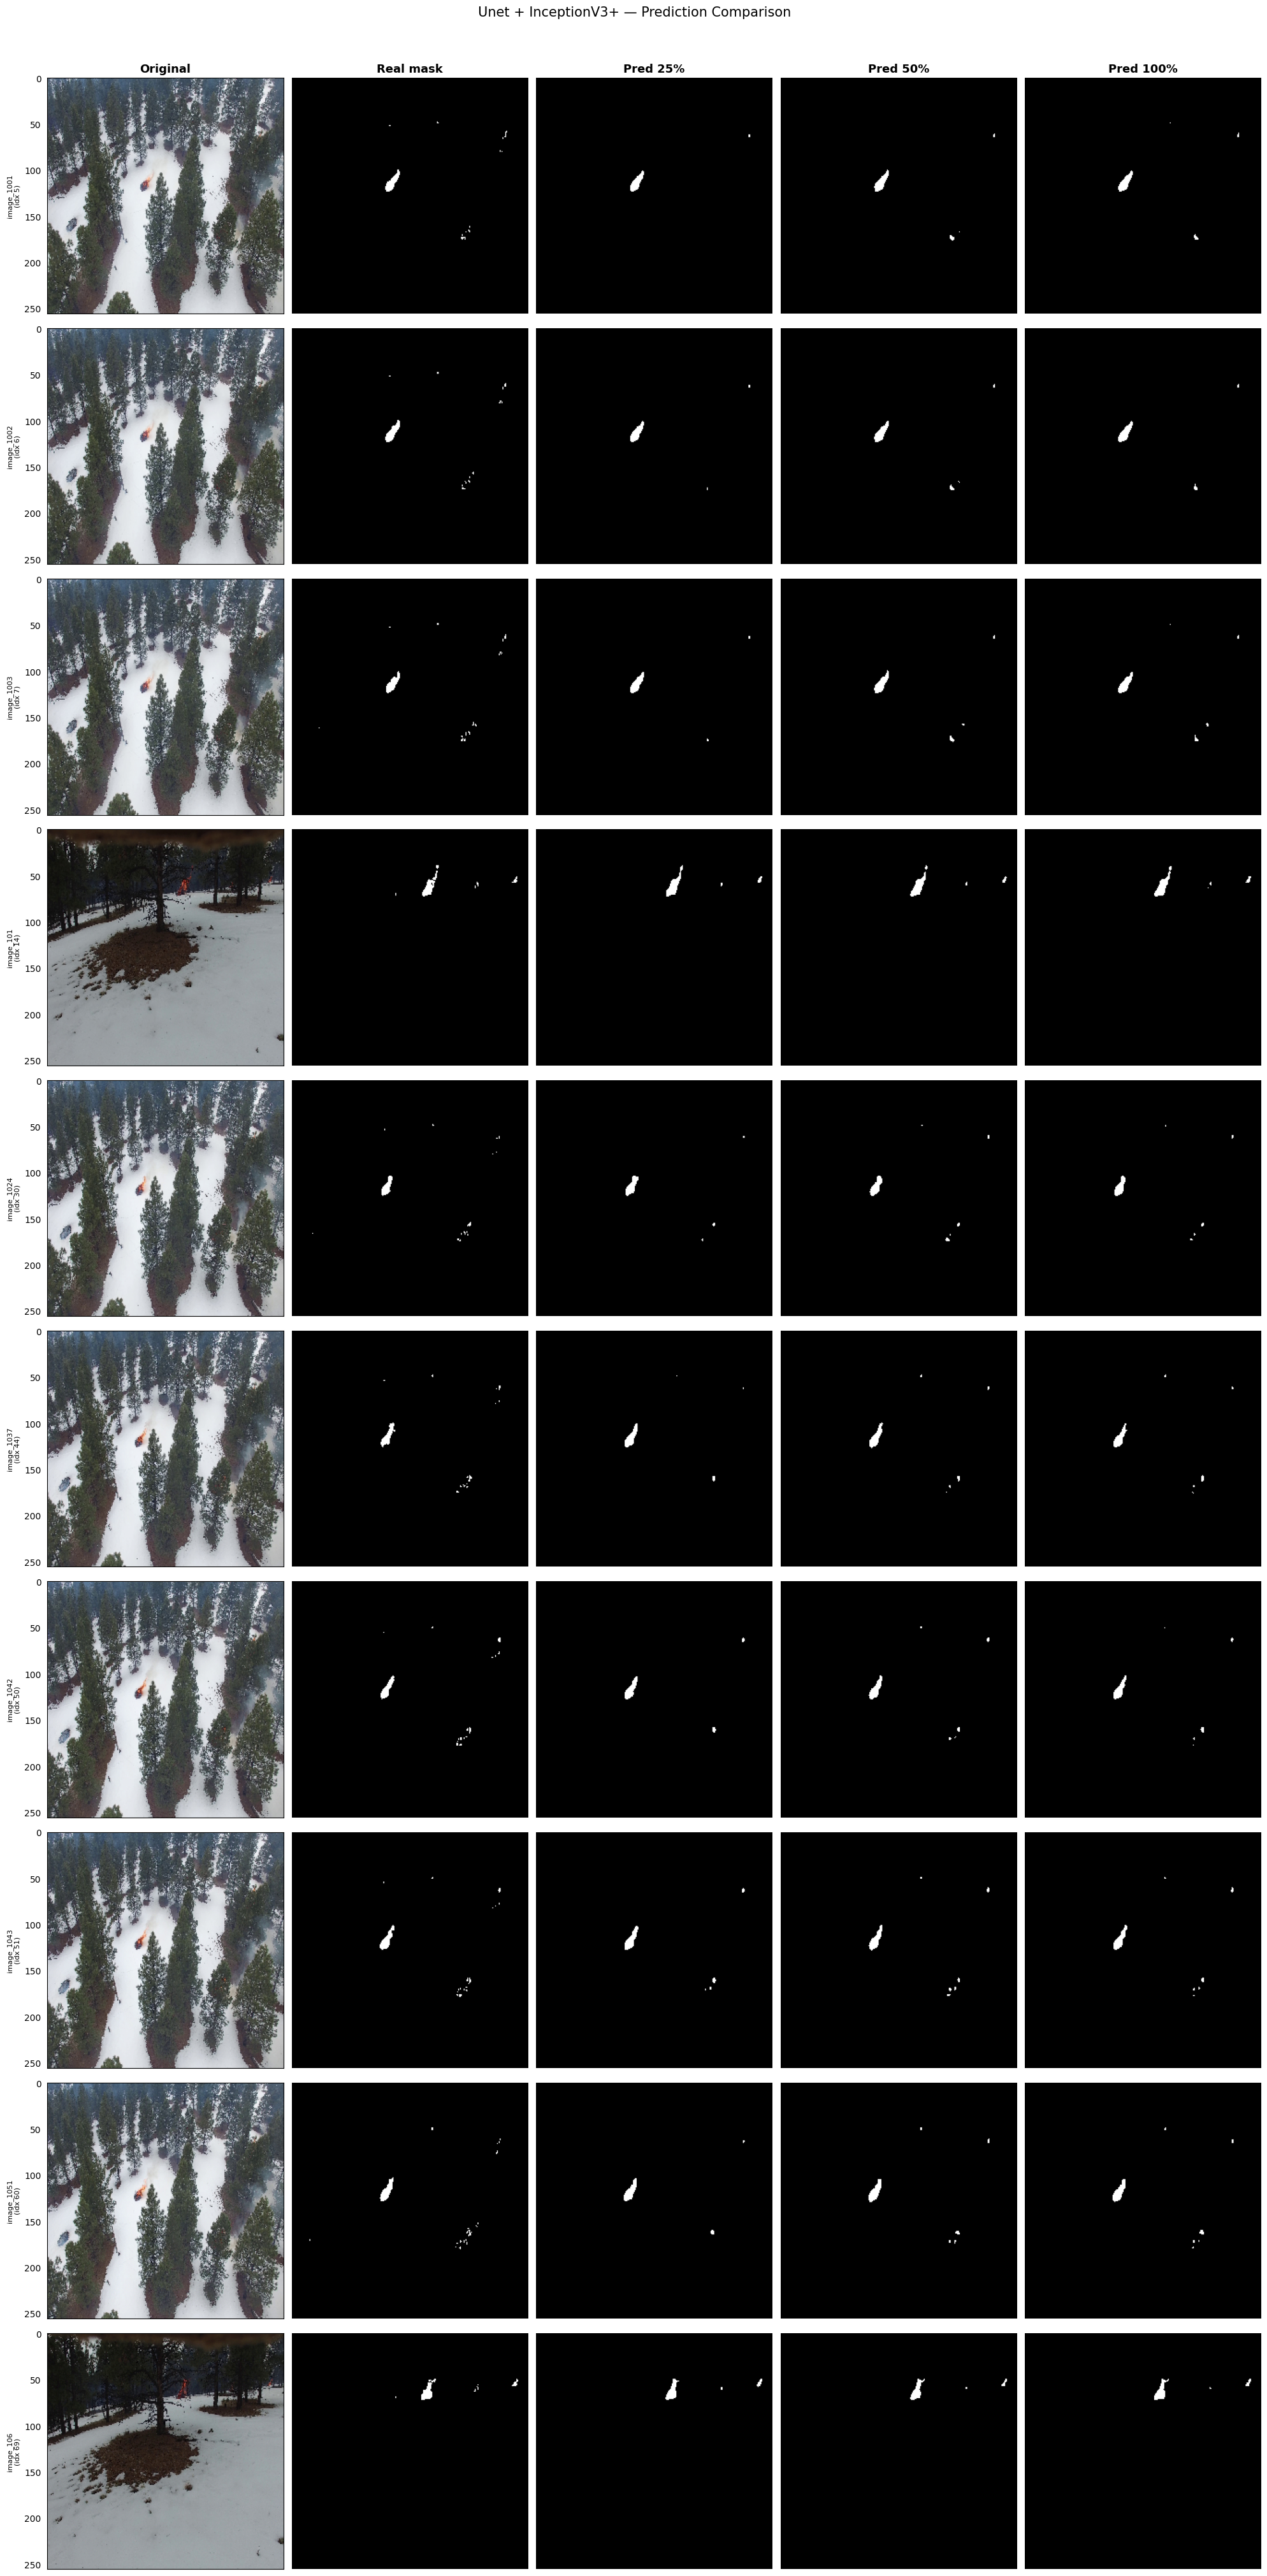

In [26]:
import matplotlib.pyplot as plt
import torch
import os

fixed_indices = [5, 6, 7, 14, 30, 44, 50, 51, 60, 69]
num_imgs = len(fixed_indices)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def predict(model, dataset, indices):
    images_list, masks_list, names_list = [], [], []
    for idx in indices:
        img, mask = dataset[idx]
        images_list.append(img)
        masks_list.append(mask)
        names_list.append(os.path.splitext(dataset.images[idx])[0])
    images = torch.stack(images_list).to(device)
    masks  = torch.stack(masks_list)
    with torch.no_grad():
        outputs = model(images)
        preds   = torch.sigmoid(outputs)
        preds   = (preds > 0.5).float()
    return images, masks, preds, names_list

full_dataset = FireDataset(images_path, masks_path, transform=val_transform)

images, masks, preds_25,  names = predict(model_25,  full_dataset, fixed_indices)
_,      _,     preds_50,  _     = predict(model_50,  full_dataset, fixed_indices)
_,      _,     preds_100, _     = predict(model_100, full_dataset, fixed_indices)

fig, axes = plt.subplots(num_imgs, 5, figsize=(20, num_imgs * 4))

col_titles = ["Original", "Real mask", "Pred 25%", "Pred 50%", "Pred 100%"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold")

for i in range(num_imgs):
    img       = images[i].cpu() * std + mean
    img       = img.permute(1, 2, 0).clamp(0, 1)
    mask_real = masks[i].cpu().squeeze()
    pred_25   = preds_25[i].cpu().squeeze()
    pred_50   = preds_50[i].cpu().squeeze()
    pred_100  = preds_100[i].cpu().squeeze()

    axes[i, 0].imshow(img)
    axes[i, 0].set_ylabel(f"{names[i]}\n(idx {fixed_indices[i]})", fontsize=8)

    axes[i, 1].imshow(mask_real, cmap="gray")
    axes[i, 2].imshow(pred_25,   cmap="gray")
    axes[i, 3].imshow(pred_50,   cmap="gray")
    axes[i, 4].imshow(pred_100,  cmap="gray")

    for col in range(5):
        axes[i, col].axis("off")
    axes[i, 0].axis("on")
    axes[i, 0].tick_params(left=False, bottom=False, labelleft=True, labelbottom=False)

plt.suptitle("Unet + InceptionV3+ — Prediction Comparison", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()